# GISLR · Stage 2 — model evaluation

**The single place where all GISLR model evaluation happens.** The four
`gislr.1.model.*.ipynb` notebooks train and stop; everything after a trained checkpoint —
leaderboard, learning curves, confusion matrices, TFLite export — is here (TODO §6). This is a
**pipeline stage**, not a diagnostic: it consumes the run registry and writes back into it.

**Where the weights are.** A run folder normally holds **no checkpoint** — `best.pt` is
uploaded to the Kaggle model `bracu23101281/signbridge-gislr` and pruned locally. Every cell
below that needs weights fetches them through `kagglehub` on demand and verifies the sha256
against `registry/checkpoints.manifest.json` before use, so there is nothing to do by hand.
Learning curves never need a checkpoint at all — they read the committed
`assets/history.json`.

**How runs are queried.** DuckDB globs every `registry/runs/*/meta.json` directly
(`sb.mlops.query`), so the leaderboard is a query over the run records themselves.
`data/models/index.csv` stays the *committed snapshot* of that query, never the query path —
it can be stale without breaking anything here.

**Ranking metric.** `accuracy = COALESCE(overall_accuracy, train_val_acc)`: the canonical
per-class eval when a run has one, otherwise the training-loop best val accuracy. Identical
to `build_model_index.py`'s `val_acc`, so the two can't disagree. Only canonical numbers are
leaderboard-legal (same split, same metric — §2 backfills the rest).

**"Tested" no longer means a Kaggle submission (2026-09-16).** GISLR moved off the live
`asl-signs` competition download to the self-produced `GISLR_Stratified` dataset, whose
`test.csv` is the split every canonical eval already scores on — that split **is** the
official held-out test set for this dataset now, not a self-computed val fraction. So §2's
canonical eval backfill marks `meta.json["submission"] = {tested: true, platform: "local"}`
itself the moment it scores a run; there is no separate submission step, and no live Kaggle
leaderboard left to submit to (the `sb.mlops.submission` Kaggle-submit machinery is kept for
reference/any future dataset with a real leaderboard, but nothing here calls it any more).

**Artifacts produced**

| artifact | path |
|---|---|
| canonical eval per run (§3), also sets `submission.tested` | `data/models/<run_id>/assets/{per_class_accuracy.csv,eval_summary.json,val_predictions.npz}` |
| top-5 learning-curve overlay | `data/cache/gislr/evaluation/top5_learning_curves.png` |
| per-run confusion matrices (top 5) | `data/cache/gislr/evaluation/confusion_<run_id>.png` |
| aggregate normalized confusion matrix | `data/cache/gislr/evaluation/confusion_all_normalized.{png,npy}` |
| most-confused class pairs | `data/cache/gislr/evaluation/confused_pairs.csv` |
| TFLite deployment export per run (§7) | `data/models/<run_id>/export/model.tflite` |

**Resumability** — §3 skips runs already evaluated (`eval_status == "canonical"`) and §7 skips
runs already exported, so both cells are safe to interrupt and re-run; neither ever redoes
finished work.

**Design decisions**

- **Confusion matrices are built from `assets/val_predictions.npz`**, written by the canonical
  eval — never by re-running inference here. One inference pass per run, ever.
- **The aggregate matrix is normalized and averaged over *all* evaluated runs.** Where
  independently-trained architectures make the *same* mistake, that confusion is a property of
  the data/labels rather than of any one model — which is exactly the Phase-1 diagnostic the
  plateau workstream needs (TODO §7.1).
- **Submission state lives in `meta.json`** (schema v3, `submission.tested`), deliberately
  dataset-agnostic — `tested` means "scored on the official/held-out test set". A dataset with
  a real Kaggle leaderboard would set `platform: "kaggle"`; GISLR sets `platform: "local"`
  because that scoring now happens locally against GISLR_Stratified's own test.csv, set
  automatically by `sb.recognize.evaluate.evaluate_run` — nothing here queues or submits
  anything any more.

**Kernel requirements**: project `.venv`, CWD = `src/`. §3 needs a CUDA GPU (inference);
§7 needs `tensorflow`.

## 1. Setup

All imports and every shared tunable. Later sections re-derive their inputs from disk, so
after running this cell any single cell below can be re-run on its own.

In [1]:
# ============================================================
# Setup — imports, tunables, resolved paths
# ============================================================
# import json
# import subprocess
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sb.mlops import registry as R
from sb.recognize.export import tflite as EX
from sb.mlops import query as SUB
from sb.recognize.report import confusion_matrix, load_history, plot_confusion
from sb.core.paths import CACHE_DIR, MODELS_DIR, gislr_dir
from sb.recognize import load_label_map

DATASET = "gislr"          # every query in this notebook is scoped to one dataset
TOP_N = 5                  # how many runs the "top" sections cover
CONFUSED_PAIRS = 30        # most-confused class pairs to extract (TODO §7.1)
FIG_DPI = 110

EVAL_DIR = CACHE_DIR / "gislr" / "evaluation"   # derived artifacts (reusable) -> cache
EVAL_DIR.mkdir(parents=True, exist_ok=True)

# label map: index -> sign name, for readable confusion-matrix axes
DATA_DIR = gislr_dir()
SIGN2IDX = load_label_map(DATA_DIR)
IDX2SIGN = {v: k for k, v in SIGN2IDX.items()}
SIGNS = [IDX2SIGN[i] for i in range(len(IDX2SIGN))]

print(f"MODELS_DIR = {MODELS_DIR}")
print(f"EVAL_DIR   = {EVAL_DIR}")
print(f"meta glob  = {R.META_GLOB}")
print(f"{len(SIGNS)} classes · schema v{R.SCHEMA_VERSION}")

MODELS_DIR = C:\Users\user2\repository\registry\runs
EVAL_DIR   = C:\Users\user2\repository\data\cache\gislr\evaluation
meta glob  = C:\Users\user2\repository\registry\runs\*\meta.json
250 classes · schema v4


## 2. Leaderboard — every GISLR run, ordered by accuracy (TODO §6.1)

DuckDB reads all `meta.json` files and returns one row per run, best first. `eval_status`
tells you whether a row is leaderboard-legal (`canonical`, from `evaluate.py` on the canonical
split) or provisional (`pending`, the training loop's own val accuracy) — §3 promotes the
pending ones.

`tested` is the schema-v3 submission flag: whether this run has been scored on GISLR's
held-out test set — set automatically by §3's canonical eval, not a separate step.

In [2]:
# ============================================================
# Leaderboard over data/models/*/meta.json (tunables: SHOW_COLUMNS, MIN_ACC)
# Pure query — re-run any time; reads nothing but the run records.
# ============================================================
SHOW_COLUMNS = ["run_id", "architecture", "subset", "coords", "accuracy", "eval_status",
                "macro_accuracy", "median_class_accuracy", "n_classes_below_50pct",
                "n_params", "streaming", "tested", "regime", "wall_time_min"]
MIN_ACC = 0.0   # raise to hide obviously broken runs

board = SUB.leaderboard(DATASET)
board = board[board["accuracy"].fillna(0) >= MIN_ACC].reset_index(drop=True)

print(f"{len(board)} {DATASET} runs · "
      f"{int((board['eval_status'] == 'canonical').sum())} canonical · "
      f"{int(board['tested'].sum())} already tested on the held-out set\n")
with pd.option_context("display.width", 220, "display.max_columns", None):
    display(board[SHOW_COLUMNS].head(20))

# per-architecture best — the architecture comparison the plateau analysis rests on
best_per_arch = (board.sort_values("accuracy", ascending=False)
                 .groupby("architecture", as_index=False).first()
                 .sort_values("accuracy", ascending=False))
print("\nbest run per architecture:")
display(best_per_arch[["architecture", "run_id", "subset", "coords",
                       "accuracy", "eval_status", "n_params", "streaming"]])

55 gislr runs · 37 canonical · 0 already tested on the held-out set



,run_id,architecture,subset,coords,accuracy,eval_status,macro_accuracy,median_class_accuracy,n_classes_below_50pct,n_params,streaming,tested,regime,wall_time_min
0,1784447175,bilstm,ME_126,xy,0.756880,canonical,0.754883,0.772811,7,2751218,False,False,v2-plateau-300,35.7
1,1789251515,gru,ME_126,xy,0.756600,pending,NaN,NaN,<NA>,851698,True,False,v2-plateau-300,11.3
2,1784453891,gru,ME_126,xy,0.756456,canonical,0.754684,0.756757,8,851698,True,False,v2-plateau-300,11.4
3,1784447187,gru,ME_126,xy,0.756456,canonical,0.754684,0.756757,8,851698,True,False,v2-plateau-300,43.0
4,1787494351,conv1d_transformer,FP_118,xy,0.754800,pending,NaN,NaN,<NA>,1830040,False,False,fp-onecycle-300,7.5
5,1784397301,bilstm,FP_118,xy,0.752540,canonical,0.750101,0.763158,10,2718418,False,False,v2-plateau-300,21.0
6,1789559734,gru,ME_132,xy,0.751800,pending,NaN,NaN,<NA>,860938,True,False,v2-plateau-300,18.2
7,1789252933,gru,FP_118,xy,0.750600,pending,NaN,NaN,<NA>,839378,True,False,v2-plateau-300,11.7
8,1784455294,gru,FP_118,xy,0.750529,canonical,0.748623,0.756757,8,839378,True,False,v2-plateau-300,11.1
9,1784451456,gru,FP_118,xy,0.750529,canonical,0.748623,0.756757,8,839378,True,False,v2-plateau-300,26.6



best run per architecture:


,architecture,run_id,subset,coords,accuracy,eval_status,n_params,streaming
0,bilstm,1784447175,ME_126,xy,0.756880,canonical,2751218,False
3,gru,1789251515,ME_126,xy,0.756600,pending,851698,True
2,conv1d_transformer,1787494351,FP_118,xy,0.754800,pending,1830040,False
5,lstm,1789256241,ME_126,xy,0.746000,pending,1113842,True
4,gru_deep,1789254670,ME_132,xy,0.742500,pending,3507466,True
1,cnn1d,1784400020,ME_132,xy,0.541384,canonical,732426,True


## 3. Canonical eval backfill

A run is only comparable — and can only have a confusion matrix — once `sb-evaluate` has
scored it on the canonical split (GISLR_Stratified's fixed 80/20 split, an 18,896-video val
set — this **is** the dataset's own held-out test set, not a self-computed val fraction). This
cell runs that eval **in-process** for every run still marked `pending`, writing
`assets/val_predictions.npz` along the way and marking `submission.tested = True` (platform
`"local"`) — there is no separate GISLR submission step any more.

Each run's `best.pt` is pulled from Kaggle first (sha256-verified) since weights are not kept
locally; pass `fetch=False` to `evaluate_run` to fail instead of downloading.

Resumable and skip-if-done: already-canonical runs are never re-evaluated, so interrupting
this cell costs at most the run in flight. ~18,896 videos of GPU inference per run.

In [3]:
# ============================================================
# Backfill canonical evals for runs still marked "pending"
# (tunables: EVAL_LIMIT, FORCE_RUN_IDS). Needs a CUDA GPU.
# Skip-if-done — safe to interrupt and re-run.
# ============================================================
EVAL_LIMIT = None        # cap how many runs this pass evaluates (None = all pending)
FORCE_RUN_IDS = []       # re-evaluate these run_ids even if already canonical

from sb.recognize.evaluate import evaluate_run

pending = SUB.query_runs(
    where=f"dataset = '{DATASET}' AND metrics.eval_status <> 'canonical' AND NOT legacy_split",
    order_by="accuracy DESC NULLS LAST")
todo = [int(r) for r in pending["run_id"]] + [int(r) for r in FORCE_RUN_IDS]
todo = list(dict.fromkeys(todo))[:EVAL_LIMIT]

# a run whose weights are gone (checkpoints are gitignored) can never be evaluated —
# report it rather than failing the whole pass
missing = [r for r in todo if not (MODELS_DIR / str(r) / R.CKPT_BEST).is_file()]
todo = [r for r in todo if r not in missing]
if missing:
    print(f"skipping {len(missing)} run(s) with no {R.CKPT_BEST} on disk: {missing}\n")

bar = tqdm(todo, desc="canonical eval", dynamic_ncols=True)
results = {}
for run_id in bar:
    bar.set_postfix_str(f"run {run_id}")
    summary = evaluate_run(MODELS_DIR / str(run_id), verbose=False)
    results[run_id] = summary
    bar.set_postfix_str(f"run {run_id} · overall {summary['overall_accuracy']:.4f}")
bar.close()

if results:
    display(pd.DataFrame(results).T[["overall_accuracy", "macro_accuracy",
                                     "median_class_accuracy", "n_classes_below_50pct"]])
    print("\nrebuild the committed index snapshot:")
    print(".venv/Scripts/python.exe src/modules/scripts/build_model_index.py")
else:
    print("nothing pending — every run with weights on disk is already canonical")

skipping 5 run(s) with no best.pt on disk: [1787494351, 1787492560, 1787493805, 1787494807, 1787495142]



canonical eval:   0%|          | 0/13 [00:00<?, ?it/s]

,overall_accuracy,macro_accuracy,median_class_accuracy,n_classes_below_50pct
1789251515,0.860129,0.858943,0.867544,0
1789559734,0.751746,0.749887,0.761579,5
1789252933,0.853355,0.852105,0.8625,0
1789258464,0.871931,0.870835,0.879189,0
1789252196,0.848698,0.847344,0.857143,0
1789256241,0.854096,0.852684,0.858059,0
1789558839,0.745025,0.742971,0.759494,3
1789257008,0.856425,0.855112,0.863606,0
1789560829,0.742485,0.740419,0.756584,9
1789254670,0.858859,0.857534,0.867544,0



rebuild the committed index snapshot:
.venv/Scripts/python.exe src/modules/scripts/build_model_index.py


## 4. Learning curves — best 5 models overlaid

One figure, all five runs: loss on the left, accuracy on the right, train dashed and val
solid. Overlaying them is what makes the plateau visible as a *shared* ceiling rather than a
per-model quirk — and the train-vs-val gap per run is the Phase-1 overfitting/underfitting
call (TODO §7.1).

Curves come from each run's `assets/history.json`; for runs trained before that asset existed,
`load_history` falls back to `last.pt` and backfills the JSON.

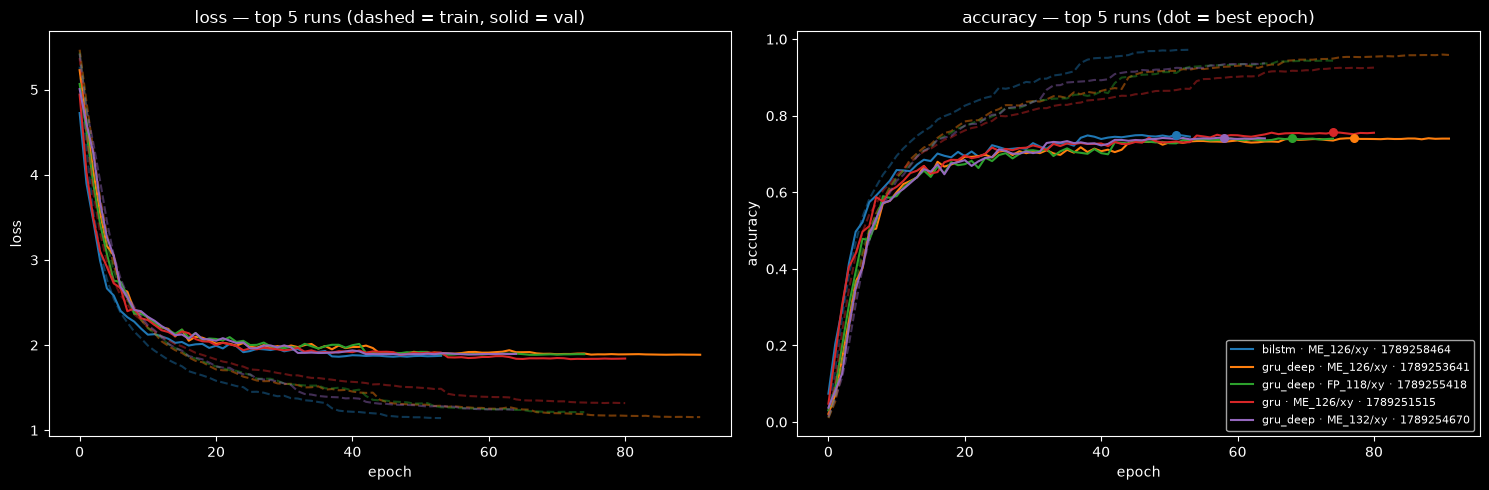

,run_id,architecture,subset,best_epoch,train_acc,val_acc,train_val_gap
0,1789251515,gru,ME_126/xy,75,0.9242,0.7566,0.1677
1,1789258464,bilstm,ME_126/xy,52,0.9716,0.7503,0.2212
2,1789254670,gru_deep,ME_132/xy,59,0.9343,0.7425,0.1918
3,1789255418,gru_deep,FP_118/xy,69,0.9424,0.7416,0.2008
4,1789253641,gru_deep,ME_126/xy,78,0.9536,0.7413,0.2123


train >> val  => overfitting: prioritize augmentation/regularization (TODO §7.4)
train ~= val  => underfitting the signal: prioritize normalization + motion (TODO §7.2/§7.3)


In [4]:
# ============================================================
# Overlay learning curves of the top-N runs (tunables: TOP_N, RUN_IDS)
# Reads assets/history.json per run — no dependency on other cells.
# ============================================================
RUN_IDS = None  # None = top TOP_N from the leaderboard; or pass an explicit list

board = SUB.leaderboard(DATASET)
run_ids = RUN_IDS or [int(r) for r in board["run_id"].head(TOP_N)]
meta_by_id = {rid: R.load_meta(MODELS_DIR / str(rid)) for rid in run_ids}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = plt.cm.tab10(np.linspace(0, 1, 10))
gaps = []
for i, rid in enumerate(run_ids):
    try:
        h = load_history(MODELS_DIR / str(rid))
    except FileNotFoundError as e:
        print(f"skipped: {e}")
        continue
    m = meta_by_id[rid]
    label = f"{m['architecture']} · {m['subset']}/{m['coords']} · {rid}"
    c = colors[i % 10]
    axes[0].plot(h["val_loss"], color=c, label=label)
    axes[0].plot(h["train_loss"], color=c, ls="--", alpha=0.45)
    axes[1].plot(h["val_acc"], color=c, label=label)
    axes[1].plot(h["train_acc"], color=c, ls="--", alpha=0.45)
    best = int(np.argmax(h["val_acc"]))
    axes[1].scatter([best], [h["val_acc"][best]], color=c, zorder=5, s=30)
    gaps.append(
        {
            "run_id": rid,
            "architecture": m["architecture"],
            "subset": f"{m['subset']}/{m['coords']}",
            "best_epoch": best + 1,
            "train_acc": round(h["train_acc"][best], 4),
            "val_acc": round(h["val_acc"][best], 4),
            "train_val_gap": round(h["train_acc"][best] - h["val_acc"][best], 4),
        }
    )

axes[0].set_title(f"loss — top {len(run_ids)} runs (dashed = train, solid = val)")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[1].set_title(f"accuracy — top {len(run_ids)} runs (dot = best epoch)")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].legend(fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(EVAL_DIR / "top5_learning_curves.png", dpi=FIG_DPI)
plt.show()

# train/val gap at the best epoch — TODO §7.1 step 2 (the overfit/underfit verdict)
gap_df = (
    pd.DataFrame(gaps).sort_values("val_acc", ascending=False).reset_index(drop=True)
)
gap_df.to_csv(EVAL_DIR / "train_val_gap.csv", index=False)
display(gap_df)
print(
    "train >> val  => overfitting: prioritize augmentation/regularization (TODO §7.4)"
)
print(
    "train ~= val  => underfitting the signal: prioritize normalization + motion (TODO §7.2/§7.3)"
)

## 5. Confusion matrices — top 5 models individually

One 250×250 row-normalized matrix per top run, built from that run's `val_predictions.npz`.
Row *i* = true class *i*, so each row sums to 1 and the diagonal is the class's recall;
off-diagonal mass is where it goes wrong. Displayed with a log-scaled color map because
off-diagonal cells are 1–2 orders of magnitude smaller than the diagonal and would otherwise
be invisible.

Full-size PNGs go to `data/cache/gislr/evaluation/`; only the figures are shown inline.

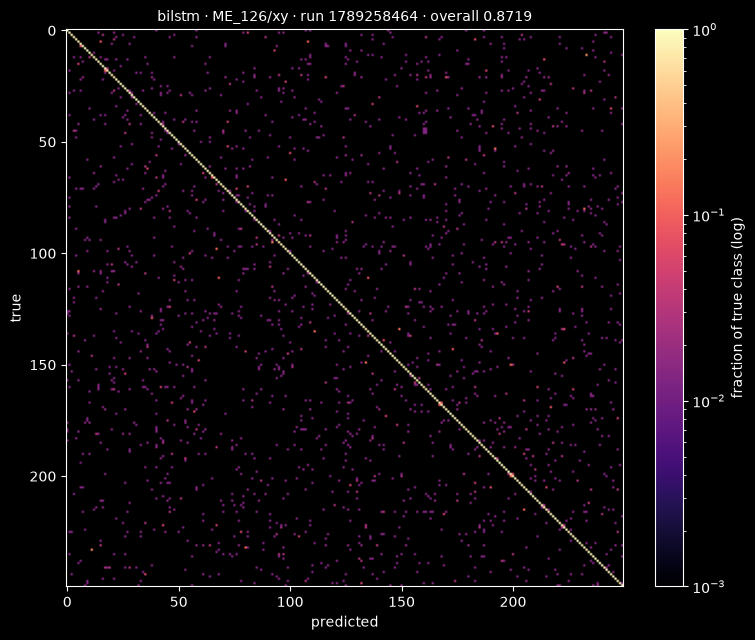

  weakest classes: beside 0.63, give 0.67, there 0.70, nap 0.71, awake 0.71, lips 0.72, vacuum 0.72, go 0.73


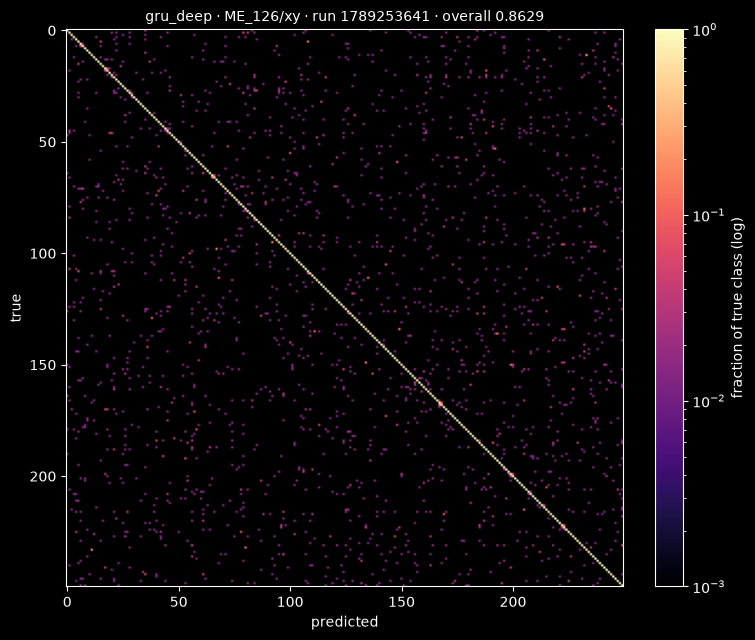

  weakest classes: vacuum 0.66, beside 0.66, give 0.67, nap 0.68, there 0.68, close 0.69, awake 0.70, empty 0.73


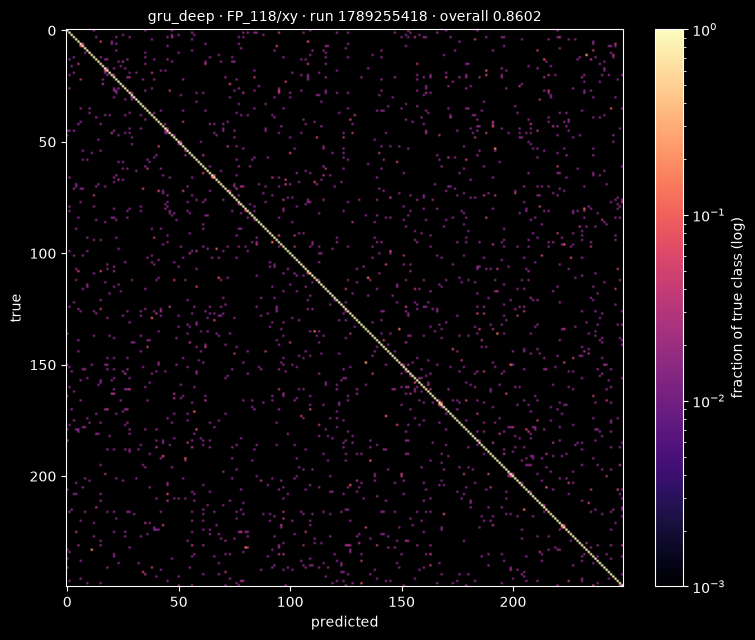

  weakest classes: mouth 0.64, give 0.65, awake 0.66, nap 0.67, there 0.67, vacuum 0.69, beside 0.69, close 0.71


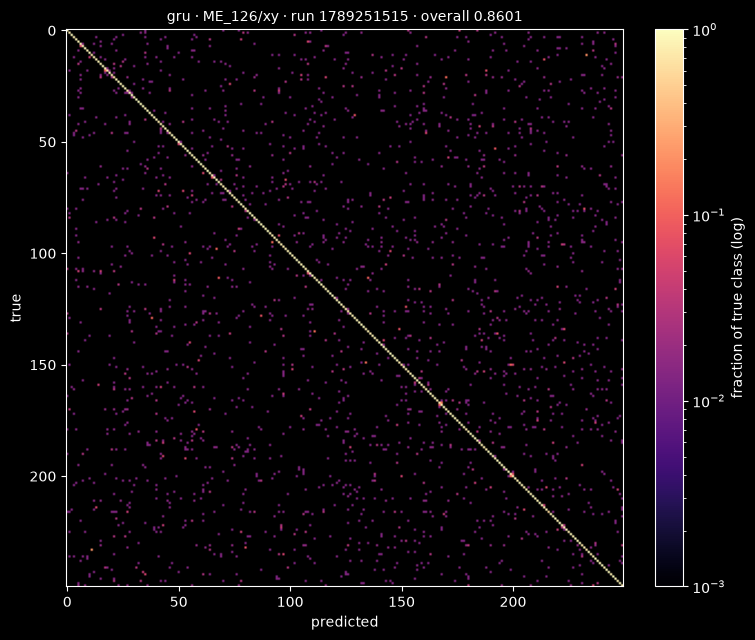

  weakest classes: there 0.59, beside 0.65, nap 0.67, wake 0.68, give 0.68, awake 0.69, vacuum 0.70, close 0.71


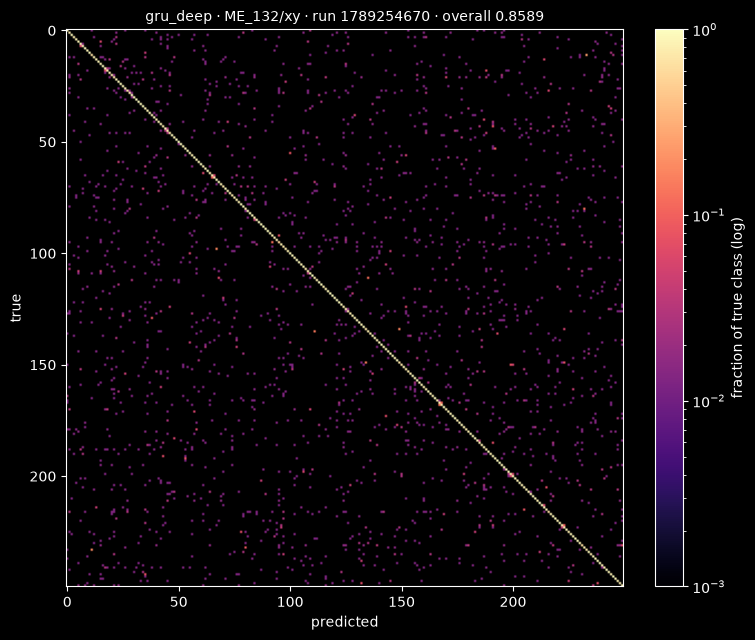

  weakest classes: give 0.57, there 0.63, vacuum 0.64, awake 0.66, beside 0.68, mouth 0.71, jeans 0.71, lips 0.72


In [5]:
# ============================================================
# Per-run confusion matrices for the top-N runs (tunables: TOP_N, RUN_IDS)
# Built from assets/val_predictions.npz — no inference here.
# ============================================================
# confusion_matrix / plot_confusion come from sb.recognize.report — shared with
# §6, so neither cell depends on the other having been run
RUN_IDS = None    # None = top TOP_N from the leaderboard

board = SUB.leaderboard(DATASET)
evaluated = board[board["eval_status"] == "canonical"]
run_ids = RUN_IDS or [int(r) for r in evaluated["run_id"].head(TOP_N)]
if not run_ids:
    print("no canonical runs yet — run §3 first")

for rid in run_ids:
    run_dir = MODELS_DIR / str(rid)
    m = R.load_meta(run_dir)
    try:
        cm = confusion_matrix(run_dir, n_classes=m["n_classes"])
    except FileNotFoundError as e:
        print(f"skipped: {e}")
        continue
    acc = m["metrics"]["overall_accuracy"]
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    im = plot_confusion(cm, f"{m['architecture']} · {m['subset']}/{m['coords']} · "
                            f"run {rid} · overall {acc:.4f}", ax)
    fig.colorbar(im, ax=ax, fraction=0.046, label="fraction of true class (log)")
    fig.tight_layout()
    fig.savefig(EVAL_DIR / f"confusion_{rid}.png", dpi=FIG_DPI)
    plt.show()

    worst = np.argsort(np.diag(cm))[:8]
    print("  weakest classes: " + ", ".join(
        f"{SIGNS[i]} {np.diag(cm)[i]:.2f}" for i in worst))

## 6. Aggregate confusion matrix — all evaluated models

The mean of the row-normalized matrices of **every** canonically-evaluated GISLR run. Averaging
normalized matrices (rather than pooling raw counts) weights each model equally regardless of
how many it got right, so the result reads as "how do models *in general* confuse these
classes".

**Why this is the useful one.** A confusion that survives averaging across independently
trained GRUs, LSTMs, BiLSTMs and CNNs is not an artifact of any architecture — it is a
property of the data, the labels, or the landmark representation. That is precisely the class
of problem the plateau workstream is chasing (TODO §7.1), and it is what the confused-pair
table below feeds.

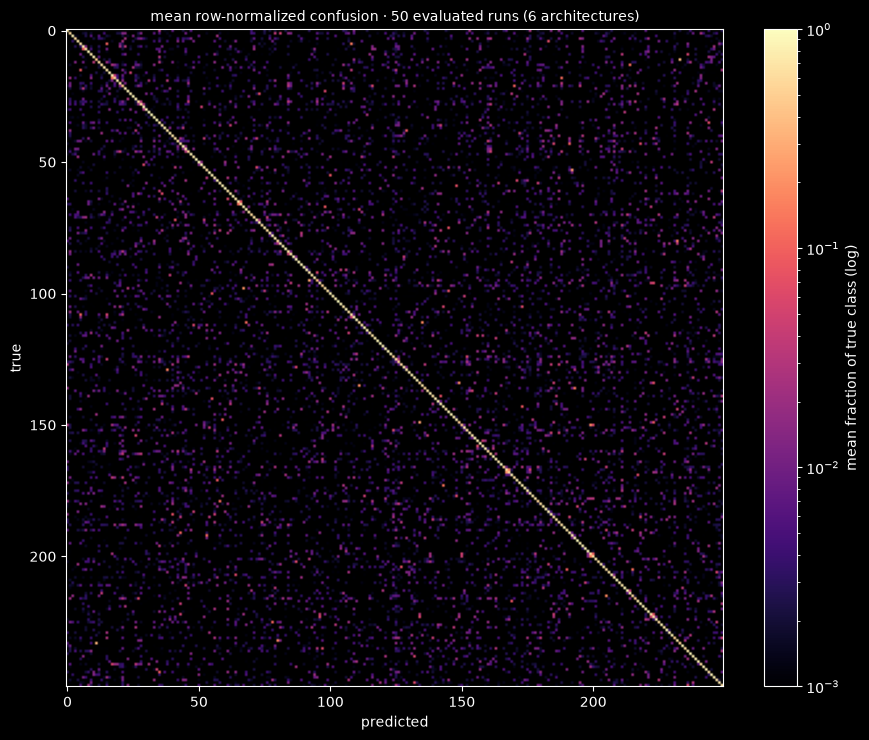

runs included: [1789258464, 1789253641, 1789255418, 1789251515, 1789254670, 1789257008, 1789256241, 1789252933, 1789252196, 1789257785, 1784447175, 1784447187, 1784453891, 1784397301, 1789559734, 1784455294, 1784451456, 1784395799, 1784449770, 1784454580, 1784459026, 1784396516, 1784393064, 1784455964, 1784447190, 1787483814, 1784399741, 1784450082, 1784456692, 1789558839, 1784393683, 1789560829, 1784400832, 1784394315, 1784459817, 1784387336, 1784390290, 1784402251, 1784457430, 1784451842, 1784385530, 1784388482, 1784389439, 1784386490, 1784400020, 1784451163, 1784449360, 1784447182, 1784399151, 1784401260]

top 30 confused pairs (mean over models) — TODO §7.1 step 4:


,true,predicted,mean_rate,true_recall,symmetric_rate
0,awake,wake,0.3605,0.4670,0.3505
1,wake,awake,0.3505,0.5002,0.3605
2,give,gift,0.2669,0.3815,0.0557
3,mouth,lips,0.2638,0.4905,0.1838
4,cut,scissors,0.2168,0.5995,0.1086
5,goose,duck,0.2134,0.6628,0.0827
6,pencil,pen,0.2123,0.5867,0.1525
7,listen,hear,0.1870,0.6951,0.1745
8,lips,mouth,0.1838,0.5934,0.2638
9,nap,sleep,0.1810,0.4156,0.0513


Next (TODO §7.1 step 5): inspect example sequences per pair and classify each as
handshape-only / motion-only / body-location — that choice decides §7.2 vs §7.3.


In [6]:
# ============================================================
# Aggregate normalized confusion matrix + most-confused pairs
# (tunables: CONFUSED_PAIRS, INCLUDE_ARCHS)
# ============================================================
INCLUDE_ARCHS = None   # None = every architecture; or e.g. ["gru", "lstm", "cnn1d"]

board = SUB.leaderboard(DATASET)
evaluated = board[board["eval_status"] == "canonical"]
if INCLUDE_ARCHS:
    evaluated = evaluated[evaluated["architecture"].isin(INCLUDE_ARCHS)]

mats, used = [], []
for rid in evaluated["run_id"]:
    try:
        mats.append(confusion_matrix(MODELS_DIR / str(int(rid))))
        used.append(int(rid))
    except FileNotFoundError:
        continue
assert mats, "no evaluated runs with cached predictions — run §3 first"

cm_all = np.mean(mats, axis=0)
np.save(EVAL_DIR / "confusion_all_normalized.npy", cm_all)

fig, ax = plt.subplots(figsize=(9, 7.5))
im = plot_confusion(cm_all, f"mean row-normalized confusion · {len(used)} evaluated runs "
                            f"({evaluated['architecture'].nunique()} architectures)", ax)
fig.colorbar(im, ax=ax, fraction=0.046, label="mean fraction of true class (log)")
fig.tight_layout()
fig.savefig(EVAL_DIR / "confusion_all_normalized.png", dpi=FIG_DPI)
plt.show()

# most-confused ordered pairs: highest off-diagonal mass, averaged over models
off = cm_all.copy()
np.fill_diagonal(off, 0.0)
flat = np.argsort(off, axis=None)[::-1][:CONFUSED_PAIRS]
pairs = pd.DataFrame([
    {"true": SIGNS[i], "predicted": SIGNS[j],
     "mean_rate": round(float(off[i, j]), 4),
     "true_recall": round(float(cm_all[i, i]), 4),
     "symmetric_rate": round(float(off[j, i]), 4)}
    for i, j in (np.unravel_index(k, off.shape) for k in flat)
])
pairs.to_csv(EVAL_DIR / "confused_pairs.csv", index=False)
print(f"runs included: {used}\n")
print(f"top {CONFUSED_PAIRS} confused pairs (mean over models) — TODO §7.1 step 4:")
display(pairs)
print("Next (TODO §7.1 step 5): inspect example sequences per pair and classify each as")
print("handshape-only / motion-only / body-location — that choice decides §7.2 vs §7.3.")

## 7. TFLite export — deployment artifact (TODO §6.2)

`sb.recognize.export` runs the full chain per run: Keras rebuild → parity → frozen
SavedModel → TFLite → validation. This is purely a deployment export now — GISLR no longer
submits anywhere, so "which runs to export" is a deployment decision (top-N, a champion, or an
explicit list), not a submission queue.

**Route: native Keras rebuild, not ONNX.** PyTorch → ONNX → `onnx2tf` was tried first and
abandoned (measured 2026-07-19): onnx2tf declares no dependencies of its own, cannot convert
the `IsInf` op `torch.nan_to_num` emits, permutes 3D input layouts, and fails outright on the
GRU, BiLSTM and CNN graphs. `sb.recognize.export.keras` instead rebuilds each architecture
with native Keras layers and transfers the trained weights — Keras' recurrent layers are on
TFLite's well-supported conversion path. All four architectures now export.

**Two parity gates, because weight transfer can fail silently.** A gate-order or bias-convention
mistake between PyTorch and Keras would convert cleanly and predict garbage, so export refuses
to write anything unless:

1. `keras_parity` — the Keras rebuild matches `forward_full` on the same input (~4e-6), and
2. `tflite_parity` — the **final .tflite file** matches PyTorch through the whole deployed path,
   raw `(T, 543, 3)` frames with NaNs in (~4e-6).

The second one already caught a real bug: `tf.lite.Optimize.DEFAULT` quantizes weights to int8
and shifted logits by ~1e-1, so quantization is off by default (these models are 3–11 MB, well
inside typical on-device size budgets, so it bought nothing).

The exported graph owns its preprocessing: NaN→0 and the landmark-subset gather are *inside* it,
and xy-trained runs drop the z column internally, so a raw `(T,543,3)` frame stream works
unchanged for every run regardless of subset or coordinate config.

**Caveat**: the exported model consumes the full sequence, while training/eval uniformly
subsample past `MAX_SEQ_LEN = 128` frames. Verify behaviour on long videos before deploying.

Requires `tensorflow` (declared in `pyproject.toml` — `uv sync` if imports fail, never ad-hoc
`uv pip install`).

In [7]:
# ============================================================
# Export runs to TFLite (tunables: EXPORT_RUN_IDS, EXPORT_LIMIT)
# Skip-if-exported — safe to interrupt and re-run.
# ============================================================
EXPORT_RUN_IDS = None    # None = top EXPORT_LIMIT canonical runs from the leaderboard; or an explicit list
EXPORT_LIMIT = 5         # cap per pass — the chain takes ~1-2 min/run
REEXPORT = False         # True = redo runs that already have an export

if EXPORT_RUN_IDS is None:
    board = SUB.leaderboard(DATASET)
    canonical = board[board["eval_status"] == "canonical"]
    EXPORT_RUN_IDS = [int(r) for r in canonical["run_id"].head(EXPORT_LIMIT)]

todo = []
for rid in EXPORT_RUN_IDS[:EXPORT_LIMIT]:
    run_dir = MODELS_DIR / str(rid)
    if not (run_dir / R.CKPT_BEST).is_file():
        print(f"run {rid}: no {R.CKPT_BEST} on disk — cannot export")
        continue
    # the exporter still names its output "submission.zip" — an unrelated
    # naming leftover from when this fed the Kaggle submission queue; it's
    # just this run's deployment package now (model.tflite + metadata)
    if not REEXPORT and (run_dir / "export" / "submission.zip").is_file():
        print(f"run {rid}: already exported (REEXPORT=True to redo)")
        continue
    todo.append(rid)

rows = []
bar = tqdm(todo, desc="export", dynamic_ncols=True)
for rid in bar:
    bar.set_postfix_str(f"run {rid}")
    try:
        rows.append(EX.export_run(MODELS_DIR / str(rid)))
        bar.set_postfix_str(f"run {rid} · {rows[-1]['size_mb']} MB")
    except Exception as e:                      # one bad run must not kill the batch
        rows.append({"run_id": rid, "error": repr(e)})
        bar.write(f"run {rid} FAILED: {e!r}")
bar.close()

if rows:
    out = pd.DataFrame(rows)
    display(out)
    if "within_size_cap" in out and not out["within_size_cap"].fillna(True).all():
        print(f"WARNING: some models exceed the {EX.TFLITE_SIZE_CAP_MB} MB size cap")
else:
    print("nothing to export")

export:   0%|          | 0/5 [00:00<?, ?it/s]

INFO:tensorflow:Assets written to: C:\Users\user2\repository\registry\runs\1789258464\export\saved_model\assets


INFO:tensorflow:Assets written to: C:\Users\user2\repository\registry\runs\1789258464\export\saved_model\assets
c:\Users\user2\repository\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


run 1789253641 FAILED: AssertionError("no Keras rebuild for architecture 'gru_deep'")
run 1789255418 FAILED: AssertionError("no Keras rebuild for architecture 'gru_deep'")
INFO:tensorflow:Assets written to: C:\Users\user2\repository\registry\runs\1789251515\export\saved_model\assets


INFO:tensorflow:Assets written to: C:\Users\user2\repository\registry\runs\1789251515\export\saved_model\assets
c:\Users\user2\repository\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


run 1789254670 FAILED: AssertionError("no Keras rebuild for architecture 'gru_deep'")


,run_id,arch,keras_parity,tflite_parity,submission_zip,size_mb,within_size_cap,output_shape,argmax,error
0,1789258464,bilstm,0.000003,0.000003,C:\Users\user2\repository\registry\runs\178925...,11.05,True,[250],69.0,NaN
1,1789253641,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"AssertionError(""no Keras rebuild for architect..."
2,1789255418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"AssertionError(""no Keras rebuild for architect..."
3,1789251515,gru,0.000003,0.000005,C:\Users\user2\repository\registry\runs\178925...,3.44,True,[250],58.0,NaN
4,1789254670,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"AssertionError(""no Keras rebuild for architect..."
